## Milestone #1 - Chris LaRosa, Mark Riglin, Sam Testa (Group #8) 

Group #8 has elected to create a "Pleaseant Weather Index (PWI)" using the following four (4) variables and weighting scale: 
1. Temperature ~ 35% 
2. Dew Point ~ 25%
3. Total Cloud Cover ~ 20%
4. Wind Speed ~ 20%

The index will ouput a value from 1 to 5, with 5 being the most pleasant conditions, and 1 being the least pleasant conditions. The PWI will use a logical color scheme of five colors to indicate which areas are included in each category. 
We intend the the index to be similar to NOAA's Winter Storm Severity Index (WSSI) in terms of the user interface, though this index will likely **not** be interactive (that is, the customer will not be able to zoom in/zoom out like WSSI). 

We believe this index will provide a simpiler, easier tool to determine how pleasant any given day may be for the general public who prefer centralized weather forecasting. 

This index is intended to be used for everyday as opposed to a singluar event/season (i.e. winter storm, tropical cyclone, etc.). 
However, the data chosen to test quality of the assignment is the three day period (every three hours) surrounding April 29, 2025. 

In [2]:
# Import statements            ...LaRosa/Testa/Riglin... 
import matplotlib.pyplot as plt
import warnings 
from herbie import Herbie, FastHerbie
import pandas as pd, numpy as np
import math 
import xarray as xr
import dask
import cartopy.crs as ccrs, cartopy.feature as cfeature
import matplotlib.dates as mdates
warnings.filterwarnings("ignore") # Ignores excessively long warning codes before cell runs are completed 

In [3]:
# Set and import run data (NAM)          ...LaRosa... 
run = pd.Timestamp("2026-4-16-00")
H = FastHerbie([run], model="nam", product="conusnest.hiresf", fxx=np.arange(0,61,3).tolist(), save_dir='./data/', overwrite=True)

# NetCDF File (commented out to avoid reloading file)    ...Riglin... 
#filename = 'nam_whole_run.nc'
#ds.to_netcdf(filename)

In [4]:
# Extract necessary variables from xarray dataset      ...Riglin/Testa... 
ss2 = '((GUST)|(TCDC)|((TMP|DPT):(2 m )))'
ss2 = H.xarray(ss2)
#combining into one xarray
ss2[1]['wsp'] = ss2[2]['gust']*2.2369362920544 
ss2[1]['tcc'] = ss2[0]['tcc']
ds = ss2[1]
#conversions and drops
ds['t2m_F'] = (ds['t2m'] - 273.15) * 9/5 + 32
ds['d2m_F'] = (ds['d2m'] - 273.15) * 9/5 + 32
#t2m_C = (ds['t2m_F'] - 32) * 5/9
#d2m_C = (ds['d2m_F'] - 32) * 5/9
#ds['wsp_ms'] = ds['wsp']
#e = 6.105 * np.exp((17.27 * d2m_C) / (237.7 + d2m_C))
#AT_C = t2m_C + 0.348 * e - 0.70 * ds['wsp_ms'] - 4.25
#ds['apparent_temp_F'] = AT_C * 9/5 + 32
#ds = ds.drop_vars('t2m') 
#ds = ds.drop_vars('d2m')
#ds['wsp'] = ds['wsp_ms'] * 2.23693629
#ds
filename = 'nam_whole_run_current.nc'
ds.to_netcdf(filename)

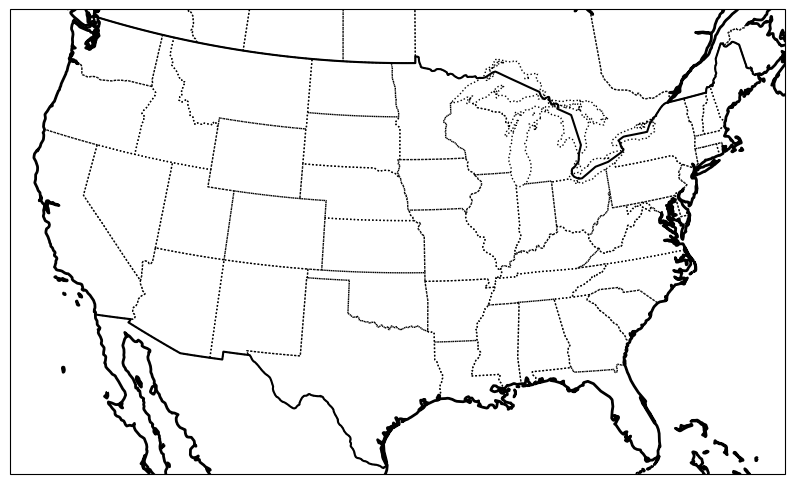

In [7]:
# GeoAxes fctn for matplotlib plots     ...LaRosa/Testa/Riglin... 
def GeoAxes():
    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(1, 1, 1, projection=ccrs.LambertConformal())
    ax.add_feature(cfeature.COASTLINE, linewidth=2)
    ax.add_feature(cfeature.BORDERS.with_scale('50m'), linewidth=1.5)
    ax.add_feature(cfeature.STATES.with_scale('50m'), linestyle=':',linewidth=1)
    ax.set_extent([-120, -73, 23, 50])
    return fig,ax
fig,ax=GeoAxes()

# Set initial time 
init_time = ds['valid_time'].values[0]
init_time = pd.to_datetime(init_time)
init_time = init_time.strftime('%HZ %a %b %d %Y')

# Set step and valid time 
run = 3
valid_time = ds['valid_time'].values[run]
valid_time = pd.to_datetime(valid_time)
valid_time = valid_time.strftime('%HZ %a %b %d %Y')

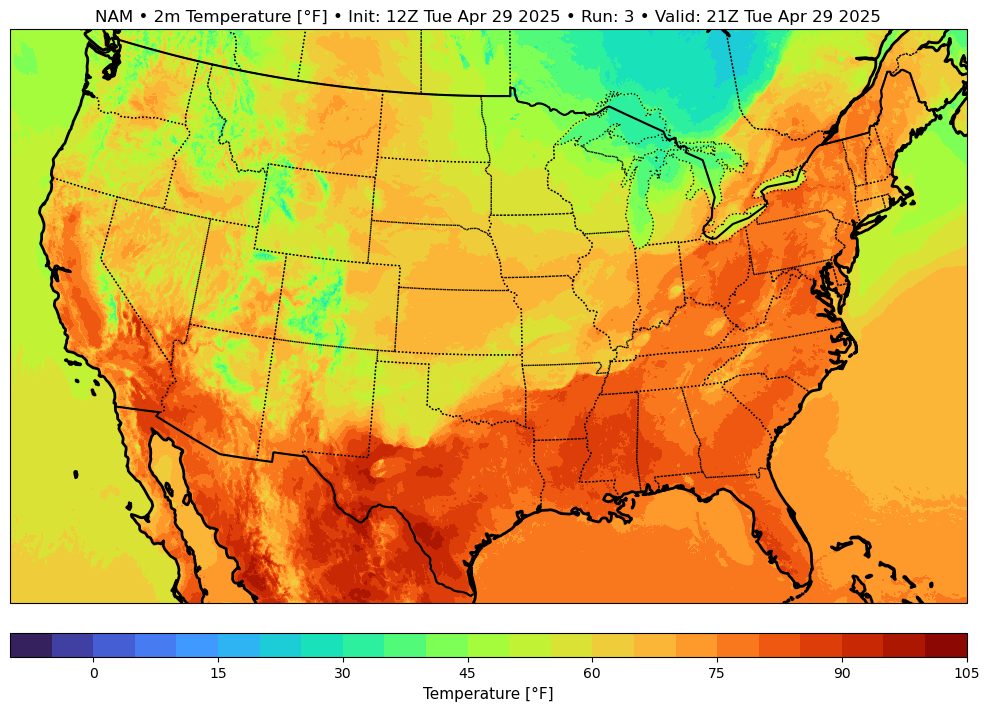

In [5]:
# PLOT #1: 2-meter Temperature [F]       ...LaRosa/Testa... 
fig, ax = GeoAxes()
dataproj = ccrs.PlateCarree()
mapproj = ccrs.LambertConformal()
ds_sub = ds.isel(y = slice(30, 1050), x = slice(90, 1760))
lat = ds_sub.latitude
lon = ds_sub.longitude
levels = np.arange(-10,106,5)
cs = ax.contourf(lon, lat, ds_sub['t2m_F'].values[run], cmap='turbo', vmin=-10,vmax = 105,levels=levels,transform=dataproj, transform_first = True)
plt.title(f"NAM \u2022 2m Temperature [°F] \u2022 Init: {init_time} \u2022 Run: {run} \u2022 Valid: {valid_time}")
cbar = plt.colorbar(cs,ax=ax,orientation="horizontal",pad=0.04,fraction=0.05,aspect=40)
cbar.set_label("Temperature [°F]", fontsize=11)
plt.tight_layout()
plt.show()

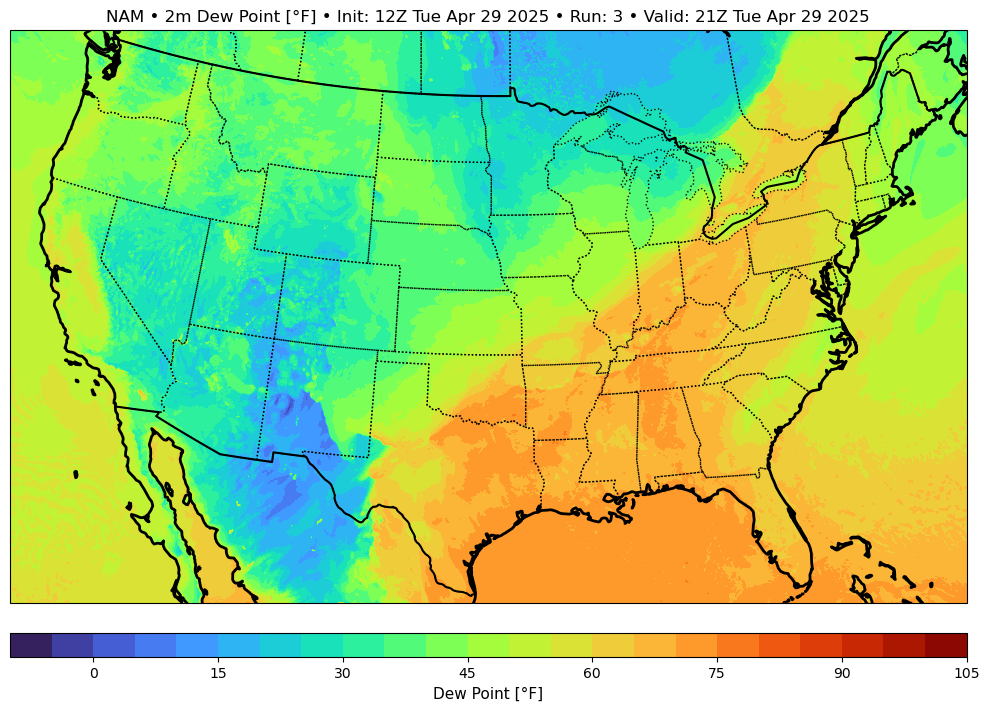

In [6]:
# PLOT #2: 2-meter Dewpoint Temperature [F]         ...LaRosa/Testa... 
fig, ax = GeoAxes()
levels = np.arange(-10,106,5)
cs = ax.contourf(lon, lat, ds_sub['d2m_F'].values[run], cmap='turbo', vmin=-10,vmax = 105,levels=levels,transform=dataproj, transform_first = True)
plt.title(f"NAM \u2022 2m Dew Point [°F] \u2022 Init: {init_time} \u2022 Run: {run} \u2022 Valid: {valid_time}")
cbar = plt.colorbar(cs,ax=ax,orientation="horizontal",pad=0.04,fraction=0.05,aspect=40)
cbar.set_label("Dew Point [°F]", fontsize=11)
plt.tight_layout()
plt.show()

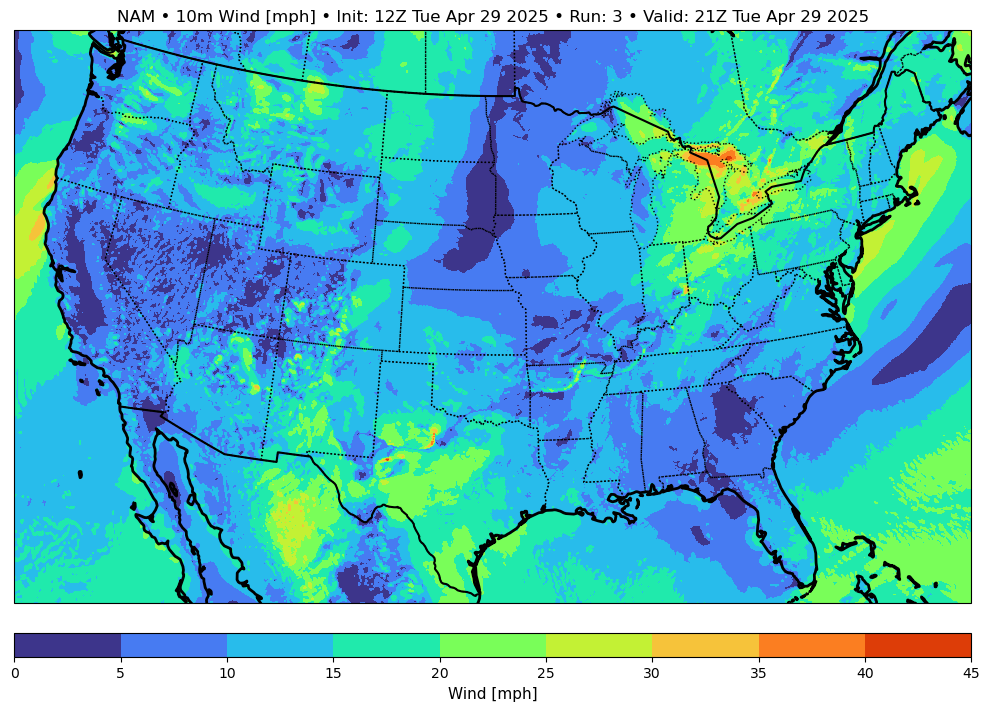

In [7]:
# PLOT #3: 10-meter Wind [mph]         ...Riglin/Testa... 
fig, ax = GeoAxes()
levels = np.arange(0,50,5)
cs = ax.contourf(lon, lat, ds_sub['wsp'].values[run], cmap='turbo', vmin=0,vmax = 50,levels=levels,transform=dataproj,transform_first = True)
plt.title(f"NAM \u2022 10m Wind [mph] \u2022 Init: {init_time} \u2022 Run: {run} \u2022 Valid: {valid_time}")
cbar = plt.colorbar(cs,ax=ax,orientation="horizontal",pad=0.04,fraction=0.05,aspect=40)
cbar.set_label("Wind [mph]", fontsize=11)
plt.tight_layout()
plt.show()

In [2]:
# Plot #4: Total Cloud Cover [%]       ...LaRosa/Riglin/Testa... 
fig, ax = GeoAxes()
levels = np.arange(0,101,10.)
cs = ax.contourf(lon, lat, ds_sub['tcc'].values[run], cmap = 'binary', vmin=0, vmax = 100, levels=levels, transform=dataproj, transform_first = True) #LJL - transform_first = True solves plotting issue
plt.title(f"NAM \u2022 Total Cloud Cover [%] \u2022 Init: {init_time} \u2022 Run: {run} \u2022 Valid: {valid_time}")
cbar = plt.colorbar(cs,ax=ax,orientation="horizontal",pad=0.04,fraction=0.05,aspect=40)
cbar.set_label("Total Cloud Cover [%]", fontsize=11)
plt.tight_layout()
plt.show()

NameError: name 'GeoAxes' is not defined

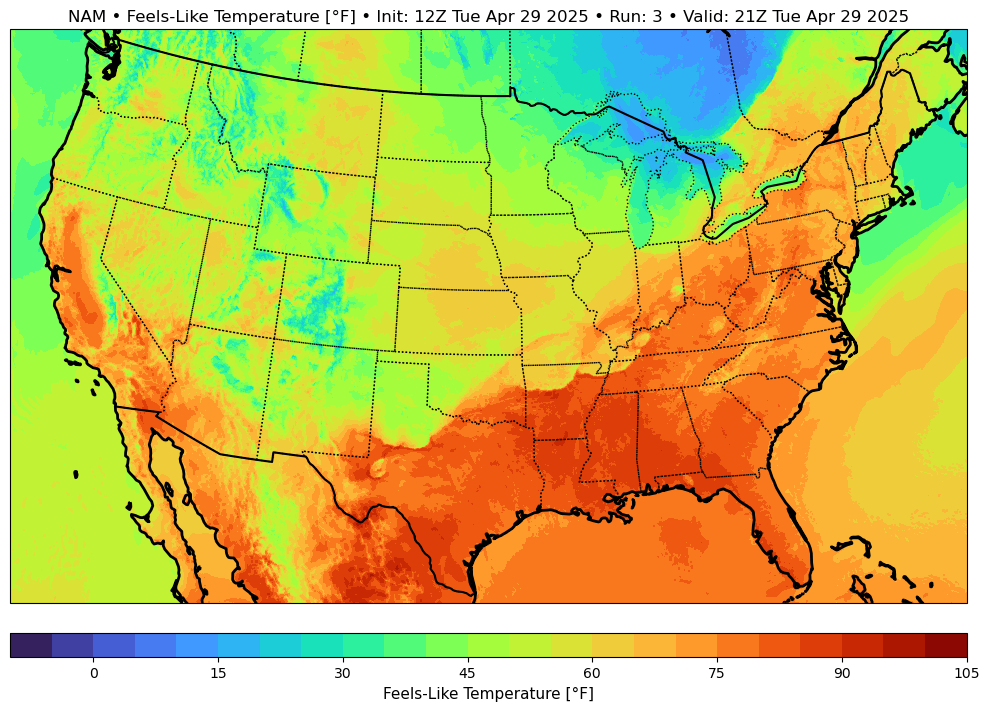

In [9]:
# Derived Variable Plot ~ Apparent ("Feels-Like") Temperature [°F]    ...Riglin/LaRosa... 
fig, ax = GeoAxes()
levels = np.arange(-10,106,5)
cs = ax.contourf(lon, lat, ds_sub['apparent_temp_F'].values[run], cmap='turbo', vmin=-10,vmax = 105,levels=levels,transform=dataproj,transform_first = True)
plt.title(f"NAM \u2022 Feels-Like Temperature [°F] \u2022 Init: {init_time} \u2022 Run: {run} \u2022 Valid: {valid_time}")
cbar = plt.colorbar(cs,ax=ax,orientation="horizontal",pad=0.04,fraction=0.05,aspect=40)
cbar.set_label("Feels-Like Temperature [°F]", fontsize=11)
plt.tight_layout()
plt.show()

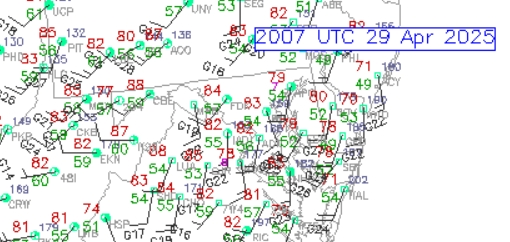

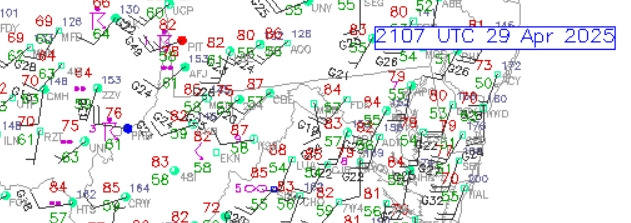

In [10]:
# Ground-truth Observations       ...Riglin... 
from IPython.display import Image, display
display(Image(filename='2007utcPIT_ob.jpeg'))
display(Image(filename='2107utcPIT_ob.jpeg')) 

#### Explanation of KPIT station model observational data (2007-2107 UTC on 29 Apr 2025)

Data recieved from UCAR Archived Station Model website. 

Tues, 29 Apr 2025 corresponds to a widespread, fast-moving line of strong and severe thunderstorms across OH and PA that produced derecho-like wind damage.  

Focus on the 'PIT' observation site and the immediately adjacent surface observing sites in eastern OH, northern WV and southwestern PA at 2007 UTC (3:07pm LDT) -- Many of the station models indicate winds btwn 15 and 20 kts, partly to mostly cloudy conditions, and surface temps in the upper 80s. 

One hour later, at 2107 UTC (4:07pm LDT), many of the stations in eastern Ohio and SW PA are reporting moderate rain or thunderstroms, with temperatures generally decreasing as the system passes. 

If we use this data and apply it to our 'Pleasant Weather Index', the index would indicate decent weather ahead of the derecho, and as the derecho approaches, and eventually passes over PIT and the surrounding areas, the index would rapidly decrease over the corresponding three-hour period. 

... Riglin ... 

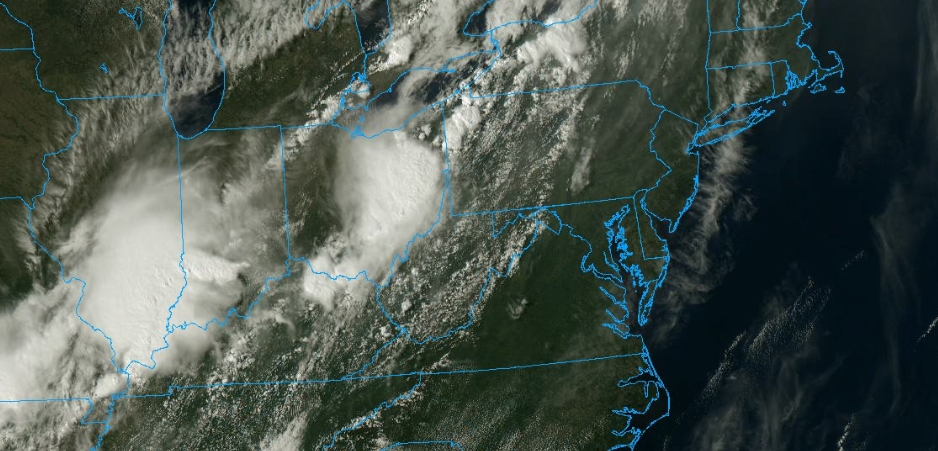

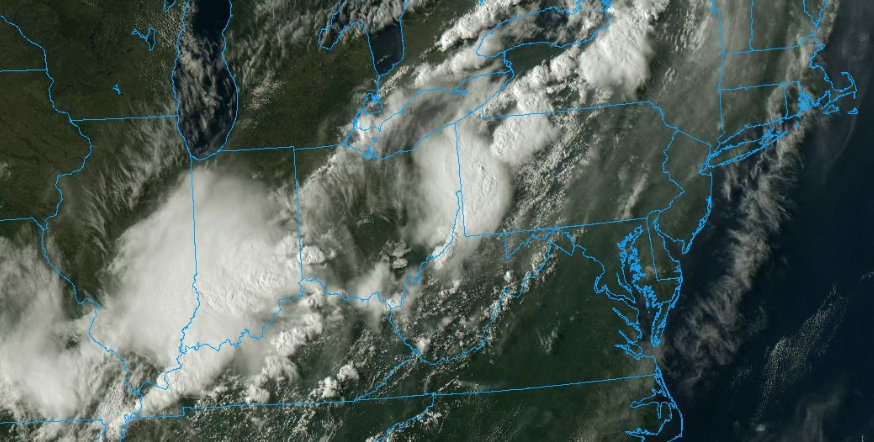

In [11]:
display(Image(filename='archivedsatdata2000utc.jpeg'))   #...Riglin... 
display(Image(filename='archivedsatdata2130utc.jpeg'))   

#### Explanation of localized satelitte data over PA/OH/WV/MD/VA (2000 UTC & 2130 UTC on 29 Apr 2025) 

Data retrieved from Iowa State University Mesonet archived satelitte website. 

2000 UTC corresponds to top-most image, 2130 UTC corresponds to the bottom-most image. 

Tues, 29 Apr 2025 corresponds to a widespread, fast-moving line of strong and severe thunderstorms across OH and PA that produced derecho-like wind damage. This data is shown to confirm surface observations (see above) and to add more context to how the index will be used to determine "pleasant and unpleasant" weather. 

Focus on the eastern OH/SW PA/NW WV area. In the 2000 UTC image, before the system of strong/severe t-storms moves through the SW PA area, most of the area is partly to mostly cloudy. In the 2100 UTC image, much of the defined area is blanketed in cloud cover and very likely, intense rainfall & strong/damaging winds. 

As previously stated, the 'Pleasant Weather Index' (PWI) will begin to drop as the storm approaches and passes over each given area, depending on the factors outlined above (temperature, cloud cover, wind speed, dew point (subject to change before MS2 completion)). 

... LaRosa/Riglin ... 